In [3]:
# Cell 1: Imports and Setup
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Set the visible device if needed (or leave it for all GPUs)
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

# Set device and random seeds for reproducibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)


In [4]:
# Cell 2: Data Loading and Preprocessing
import pandas as pd

# Load your data (adjust the file paths as needed)
df_hemo = pd.read_csv(os.path.expanduser('~/merged_hemorrhage_embeddings.csv'))
df_control = pd.read_csv(os.path.expanduser('~/merged_control_embeddings.csv'))

# Combine the two DataFrames.
df = pd.concat([df_hemo, df_control], ignore_index=True)

# Convert the 'embedding' column from string to a list (use ast.literal_eval if preferred)
df['embedding'] = df['embedding'].apply(eval)

# Define the target columns (order matters)
target_columns = ['any', 'epidural', 'intraparenchymal', 
                  'intraventricular', 'subarachnoid', 'subdural']

# Extract features and labels
X = np.array(df['embedding'].tolist(), dtype=np.float32)  # shape (N, 1408)
y = df[target_columns].values.astype(np.float32)           # shape (N, 6)

# (Optional) Normalize X (here using a simple standardization)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Reshape flat embeddings into sequences.
# For an embedding size of 1408, one possible reshape is 16 tokens each of size 88 since 16*88=1408.
sequence_length = 16
feature_dim = 88
X_seq = X.reshape(-1, sequence_length, feature_dim)  # shape: (num_samples, 16, 88)

# Split into train and test sets.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_seq, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)  # e.g., (num_samples, 16, 88)
print("y_train shape:", y_train.shape)


X_train shape: (12900, 16, 88)
y_train shape: (12900, 6)


In [5]:
# Cell 3: Dataset
class EmbeddingDataset(Dataset):
    def __init__(self, X, y=None):
        """
        X: np.array of shape (num_samples, sequence_length, feature_dim)
        y: np.array of shape (num_samples, 6) or None for inference
        """
        self.X = torch.tensor(X, dtype=torch.float32)
        if y is not None:
            self.y = torch.tensor(y, dtype=torch.float32)
        else:
            self.y = None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is not None:
            return self.X[idx], self.y[idx]
        else:
            return self.X[idx]

# Create dataset and dataloader objects
train_dataset = EmbeddingDataset(X_train, y_train)
test_dataset = EmbeddingDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)


In [6]:
# Cell 4: Define the Custom Model with Cross-Branches and Temperature Scaling
class MySequenceModel(nn.Module):
    def __init__(self, input_dim, seq_len, hidden_dim, num_gru_layers=2, drop_out=0.5, temperature=0.5):
        """
        input_dim: the flat embedding size (e.g., 1408)
        seq_len: sequence length (e.g., 16)
        hidden_dim: GRU hidden dimension (an integer, e.g., 128)
        temperature: scaling factor to squeeze outputs toward 0 or 1
        """
        super(MySequenceModel, self).__init__()
        self.seq_len = seq_len
        self.feature_dim = input_dim // seq_len  # e.g. 1408 // 16 = 88
        self.temperature = temperature
        
        # Branch 1: Convolutional branch—
        # Reshape will be (batch, 1, seq_len, feature_dim)
        self.conv_branch = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=(1,3), padding=(0,1), bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(drop_out),
            nn.Conv2d(64, 32, kernel_size=(1,3), padding=(0,1), bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(drop_out)
        )
        # After conv: output shape -> (batch, 32, seq_len, feature_dim)
        # We'll flatten the conv branch output:
        self.fc_conv = nn.Linear(32 * self.seq_len * self.feature_dim, 128)  # compress features
        
        # Branch 2: GRU branch—
        # Input: (batch, seq_len, feature_dim)
        self.gru = nn.GRU(self.feature_dim, hidden_dim, num_layers=num_gru_layers, 
                          batch_first=True, bidirectional=True, dropout=drop_out)
        # We'll take the last time-step output: shape (batch, hidden_dim*2)
        
        # Combine branches:
        combined_dim = 128 + hidden_dim * 2
        
        # Fully connected layers with decreasing units
        self.fc_final = nn.Sequential(
            nn.Linear(combined_dim, 64),
            nn.ReLU(),
            nn.Dropout(drop_out),
            nn.Linear(64, 6)  # outputs: 6 probabilities
        )
        
    def forward(self, x):
        """
        x: tensor of shape (batch, seq_len, feature_dim)
        """
        batch_size = x.size(0)
        # Branch 1 (convolution branch):
        x_conv = x.unsqueeze(1)  # (batch, 1, seq_len, feature_dim)
        x_conv = self.conv_branch(x_conv)  # (batch, 32, seq_len, feature_dim)
        x_conv = x_conv.view(batch_size, -1)  # flatten: (batch, 32*seq_len*feature_dim)
        x_conv = self.fc_conv(x_conv)  # (batch, 128)
        
        # Branch 2 (GRU branch):
        x_gru, _ = self.gru(x)  # (batch, seq_len, hidden_dim*2)
        x_gru = x_gru[:, -1, :]  # take last timestep: (batch, hidden_dim*2)
        
        # Combine branches:
        combined = torch.cat([x_conv, x_gru], dim=1)  # (batch, 128 + hidden_dim*2)
        logits = self.fc_final(combined)  # (batch, 6)
        # Apply temperature scaling before sigmoid:
        scaled_logits = logits / self.temperature
        outputs = torch.sigmoid(scaled_logits)
        return outputs

# Example initialization:
input_dim = 1408   # original flat embedding size
seq_len = 16       # as used in data reshape
hidden_dim = 128   # GRU hidden dimension
model = MySequenceModel(input_dim=input_dim, seq_len=seq_len, hidden_dim=hidden_dim, drop_out=0.5, temperature=0.5)
model = model.to(device)
print(model)


MySequenceModel(
  (conv_branch): Sequential(
    (0): Conv2d(1, 64, kernel_size=(1, 3), stride=(1, 1), padding=(0, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Conv2d(64, 32, kernel_size=(1, 3), stride=(1, 1), padding=(0, 1), bias=False)
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.5, inplace=False)
  )
  (fc_conv): Linear(in_features=45056, out_features=128, bias=True)
  (gru): GRU(88, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc_final): Sequential(
    (0): Linear(in_features=384, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=64, out_features=6, bias=True)
  )
)


In [7]:
# Cell 5: Custom Competition Loss Function
def comp_loss_fn(pred, target, weights=[2.0, 1.0, 1.0, 1.0, 1.0, 1.0]):
    """
    pred, target: tensors of shape (batch, 6)
    weights: list of weights for each label, with the first ("any") weighted higher.
    """
    loss = 0.0
    for i in range(6):
        loss += weights[i] * F.binary_cross_entropy(pred[:, i], target[:, i], reduction='mean')
    return loss / sum(weights)


In [8]:
# Cell 6: Training Loop
num_epochs = 50
optimizer = optim.Adam(model.parameters(), lr=3e-4)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[20, 30, 40], gamma=0.1)

model.train()
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for batch in train_loader:
        inputs, labels = batch
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)  # outputs shape: (batch, 6)
        loss = comp_loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * inputs.size(0)
    
    epoch_loss = epoch_loss / len(train_dataset)
    scheduler.step()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")


Epoch [1/50], Loss: 0.4543
Epoch [2/50], Loss: 0.4149
Epoch [3/50], Loss: 0.3984
Epoch [4/50], Loss: 0.3875
Epoch [5/50], Loss: 0.3847
Epoch [6/50], Loss: 0.3775
Epoch [7/50], Loss: 0.3760
Epoch [8/50], Loss: 0.3712
Epoch [9/50], Loss: 0.3698
Epoch [10/50], Loss: 0.3630
Epoch [11/50], Loss: 0.3603
Epoch [12/50], Loss: 0.3581
Epoch [13/50], Loss: 0.3533
Epoch [14/50], Loss: 0.3512
Epoch [15/50], Loss: 0.3476
Epoch [16/50], Loss: 0.3412
Epoch [17/50], Loss: 0.3368
Epoch [18/50], Loss: 0.3345
Epoch [19/50], Loss: 0.3271
Epoch [20/50], Loss: 0.3254
Epoch [21/50], Loss: 0.3102
Epoch [22/50], Loss: 0.3077
Epoch [23/50], Loss: 0.3047
Epoch [24/50], Loss: 0.3028
Epoch [25/50], Loss: 0.3033
Epoch [26/50], Loss: 0.3011
Epoch [27/50], Loss: 0.3008
Epoch [28/50], Loss: 0.2982
Epoch [29/50], Loss: 0.2989
Epoch [30/50], Loss: 0.2970
Epoch [31/50], Loss: 0.2970
Epoch [32/50], Loss: 0.2963
Epoch [33/50], Loss: 0.2947
Epoch [34/50], Loss: 0.2943
Epoch [35/50], Loss: 0.2946
Epoch [36/50], Loss: 0.2939
E

In [9]:
# Cell 7: Evaluation
model.eval()
test_loss = 0.0
with torch.no_grad():
    for batch in test_loader:
        inputs, labels = batch
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = comp_loss_fn(outputs, labels)
        test_loss += loss.item() * inputs.size(0)
        
test_loss = test_loss / len(test_dataset)
print(f"Test Loss: {test_loss:.4f}")

# Print sample predictions
with torch.no_grad():
    for i, (inputs, labels) in enumerate(test_loader):
        inputs = inputs.to(device)
        outputs = model(inputs)
        print(f"Sample {i+1} predictions:")
        for j, col in enumerate(['any', 'epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']):
            print(f"  {col}: {outputs[0][j].item():.4f}")
        if i >= 4:
            break


Test Loss: 0.3933
Sample 1 predictions:
  any: 0.5686
  epidural: 0.0412
  intraparenchymal: 0.3536
  intraventricular: 0.2566
  subarachnoid: 0.2732
  subdural: 0.2681
Sample 2 predictions:
  any: 0.9973
  epidural: 0.0339
  intraparenchymal: 0.6074
  intraventricular: 0.4297
  subarachnoid: 0.4388
  subdural: 0.4324
Sample 3 predictions:
  any: 0.9959
  epidural: 0.0360
  intraparenchymal: 0.5886
  intraventricular: 0.4174
  subarachnoid: 0.4307
  subdural: 0.4299
Sample 4 predictions:
  any: 0.7279
  epidural: 0.0746
  intraparenchymal: 0.4627
  intraventricular: 0.3482
  subarachnoid: 0.3635
  subdural: 0.3546
Sample 5 predictions:
  any: 0.6114
  epidural: 0.0599
  intraparenchymal: 0.4217
  intraventricular: 0.3175
  subarachnoid: 0.3321
  subdural: 0.3274


Temperature: 0.1, Validation Competition Loss: 1.3676
Temperature: 0.3, Validation Competition Loss: 0.8069
Temperature: 0.5, Validation Competition Loss: 0.7315
Temperature: 0.7, Validation Competition Loss: 0.7092
Temperature: 1.0, Validation Competition Loss: 0.6979


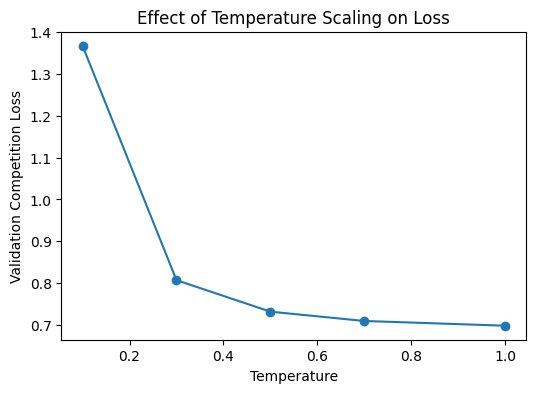

In [10]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

def apply_temperature_scaling(logits, temperature):
    """
    Applies temperature scaling to logits and returns predictions between 0 and 1.
    Arguments:
      logits: Tensor of shape (batch, 6)
      temperature: scalar temperature (< 1 makes sigmoid steeper)
    """
    scaled_logits = logits / temperature
    return torch.sigmoid(scaled_logits)

def evaluate_temperature(model, val_loader, temperature):
    """
    Iterates through validation loader, applies temperature scaling with parameter T,
    and computes the average competition loss.
    """
    model.eval()
    total_loss = 0.0
    total_samples = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            # Assume your model outputs raw logits (without temperature scaling applied)
            logits = model(inputs)  # if your model already applies sigmoid internally, you may need to modify your model to output logits.
            
            # If your model already applies sigmoid, modify your model temporarily,
            # or extract the pre-sigmoid output. Here, we assume `logits` are raw.
            preds = apply_temperature_scaling(logits, temperature)
            loss = comp_loss_fn(preds, labels)  # Use your custom competition loss
            total_loss += loss.item() * inputs.size(0)
            total_samples += inputs.size(0)
    return total_loss / total_samples

# Experiment with different temperatures:
temperature_values = [0.1, 0.3, 0.5, 0.7, 1.0]
losses = []
for T in temperature_values:
    val_loss_T = evaluate_temperature(model, test_loader, T)
    print(f"Temperature: {T}, Validation Competition Loss: {val_loss_T:.4f}")
    losses.append(val_loss_T)

plt.figure(figsize=(6,4))
plt.plot(temperature_values, losses, marker='o')
plt.xlabel("Temperature")
plt.ylabel("Validation Competition Loss")
plt.title("Effect of Temperature Scaling on Loss")
plt.show()


OHEM Percent: 0.05, Validation Loss: 0.9262
OHEM Percent: 0.1, Validation Loss: 0.8742
OHEM Percent: 0.25, Validation Loss: 0.7999
OHEM Percent: 0.5, Validation Loss: 0.7548


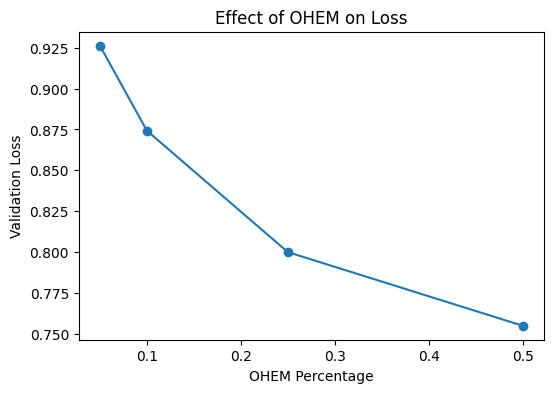

In [11]:
def ohem_loss_fn(pred, target, OHEM_percent):
    """
    Compute binary cross entropy loss per element, then pick the top OHEM_percent of samples (by loss)
    and average their loss.
    """
    # Compute elementwise BCE loss.
    elem_loss = F.binary_cross_entropy(pred, target, reduction='none')
    # Average per sample (assuming pred and target shape: (batch, 6))
    sample_loss = elem_loss.mean(dim=1)  
    # Get the top k percent losses: note that higher loss values are "harder".
    k = max(1, int(sample_loss.size(0) * OHEM_percent))
    topk_loss, _ = torch.topk(sample_loss, k=k, largest=True, sorted=True)
    return topk_loss.mean()

def evaluate_ohem(model, val_loader, OHEM_percent):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            preds = model(inputs)
            # Apply sigmoid if not already applied (assume model output are logits)
            preds = torch.sigmoid(preds)
            loss = ohem_loss_fn(preds, labels, OHEM_percent)
            total_loss += loss.item() * inputs.size(0)
            total_samples += inputs.size(0)
    return total_loss / total_samples

# Experiment with different OHEM percentages:
ohem_percents = [0.05, 0.1, 0.25, 0.5]  # e.g., top 5%, 10%, 25%, 50%
ohem_losses = []
for p in ohem_percents:
    val_loss = evaluate_ohem(model, test_loader, p)
    print(f"OHEM Percent: {p}, Validation Loss: {val_loss:.4f}")
    ohem_losses.append(val_loss)

plt.figure(figsize=(6,4))
plt.plot(ohem_percents, ohem_losses, marker='o')
plt.xlabel("OHEM Percentage")
plt.ylabel("Validation Loss")
plt.title("Effect of OHEM on Loss")
plt.show()


In [12]:
from sklearn.model_selection import KFold

def train_one_fold(train_idx, val_idx):
    # Create train/validation datasets
    X_train_fold, X_val_fold = X_train[val_idx], X_train[val_idx]
    y_train_fold, y_val_fold = y_train[val_idx], y_train[val_idx]
    
    train_dataset = EmbeddingDataset(X_train_fold, y_train_fold)
    val_dataset = EmbeddingDataset(X_val_fold, y_val_fold)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Reinitialize model (or copy the base model)
    fold_model = MySequenceModel(input_dim=1408, seq_len=sequence_length, hidden_dim=128, drop_out=0.5, temperature=0.5)
    fold_model = fold_model.to(device)
    optimizer = optim.Adam(fold_model.parameters(), lr=3e-4)
    num_epochs = 10  # For an experiment, fewer epochs
    
    for epoch in range(num_epochs):
        fold_model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = fold_model(inputs)
            loss = comp_loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
    
    # Evaluate on validation fold:
    fold_model.eval()
    total_val_loss = 0.0
    total_samples = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = fold_model(inputs)
            loss = comp_loss_fn(torch.sigmoid(outputs), labels)
            total_val_loss += loss.item() * inputs.size(0)
            total_samples += inputs.size(0)
            
    return total_val_loss / total_samples

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_losses = []
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"Training fold {fold}")
    val_loss = train_one_fold(train_idx, val_idx)
    fold_losses.append(val_loss)
    print(f"Fold {fold} Validation Loss: {val_loss:.4f}")

print("Average CV Loss:", np.mean(fold_losses))


Training fold 0
Fold 0 Validation Loss: 0.7144
Training fold 1
Fold 1 Validation Loss: 0.7059
Training fold 2
Fold 2 Validation Loss: 0.7141
Training fold 3
Fold 3 Validation Loss: 0.7170
Training fold 4
Fold 4 Validation Loss: 0.7104
Average CV Loss: 0.7123509400020274


In [ ]:
# Cell 8: Saving and Inference (Optional)
MODEL_SAVE_PATH = './best_model.pt'
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print("Model saved.")

# For inference on new test embeddings (assume X_test_seq for test set):
model.eval()
all_preds = []
with torch.no_grad():
    for batch in test_loader:
        inputs, _ = batch  # If labels are not available, just work with inputs.
        inputs = inputs.to(device)
        preds = model(inputs)
        all_preds.append(preds.cpu().numpy())
all_preds = np.concatenate(all_preds, axis=0)
print("Predictions shape:", all_preds.shape)

# If you need to save a submission CSV (assuming you have corresponding filenames):
import pandas as pd
filenames = [f"sample_{i}" for i in range(len(all_preds))]  # Replace with actual filenames if available
df_submit = pd.DataFrame(all_preds, columns=['any', 'epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural'])
df_submit['filename'] = filenames
# Optionally reformat (e.g., melt) if required by submission format.
df_submit.to_csv("submission.csv", index=False)
print("Submission file saved.")


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

if 'accuracy' in history.history:
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()

plt.tight_layout()
plt.show()
